In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load data
data = pd.read_excel("/content/indonesia_population1.xlsx")
df = pd.DataFrame(data)

# Normalisasi data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[['Year']])
y_scaled = scaler_y.fit_transform(df[['Population']])

# Jumlah lipatan
num_folds = 10
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Inisialisasi metrik evaluasi
mse_scores = []
r2_scores = []
all_train_loss = []
all_val_loss = []

In [26]:
# Loop melalui setiap lipatan
for fold, (train_index, test_index) in enumerate(kf.split(X_scaled), 1):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y_scaled[train_index], y_scaled[test_index]

    # Bangun model
    model = Sequential()
    model.add(Dense(units=6, activation='relu', input_dim=1))
    model.add(Dropout(0.2))  # Tambahkan dropout di antara layer
    model.add(Dense(units=1, activation='linear'))

    # Kompilasi model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Latih model dan simpan riwayat pelatihan
    history = model.fit(X_train, y_train, epochs=1000, batch_size=32, verbose=0, validation_data=(X_test, y_test))

    # Evaluasi model pada data uji
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mse_scores.append(mse)
    r2_scores.append(r2)

    # Cetak hasil setiap lipatan
    print(f'Fold {fold}:')
    print(f'MSE: {mse}')
    print(f'R^2 Score: {r2}')
    print()

    # Simpan loss pelatihan dan validasi
    all_train_loss.append(history.history['loss'])
    all_val_loss.append(history.history['val_loss'])

# Cetak hasil cross-validation
print(f'Mean MSE across folds: {np.mean(mse_scores)}')
print(f'Mean R^2 across folds: {np.mean(r2_scores)}')

1/1 [==============================] - 0s 105ms/step
Fold 1:
MSE: 0.009167939497257761
R^2 Score: 0.8966090036102423

1/1 [==============================] - 0s 53ms/step
Fold 2:
MSE: 0.007949845822497513
R^2 Score: 0.9351802106273983

1/1 [==============================] - 0s 78ms/step
Fold 3:
MSE: 0.0069928339885111795
R^2 Score: 0.944541957609374

1/1 [==============================] - 0s 51ms/step
Fold 4:
MSE: 0.0035868398327926583
R^2 Score: 0.9629996242369726

1/1 [==============================] - 0s 72ms/step
Fold 5:
MSE: 0.011960113051407957
R^2 Score: 0.8826838908968024

1/1 [==============================] - 0s 53ms/step
Fold 6:
MSE: 0.015356143381519069
R^2 Score: 0.8747392145604104

1/1 [==============================] - 0s 86ms/step
Fold 7:
MSE: 0.004926182165127285
R^2 Score: 0.6920138191185974

1/1 [==============================] - 0s 50ms/step
Fold 8:
MSE: 0.003800003909266664
R^2 Score: 0.8776354732745831

1/1 [==============================] - 0s 59ms/step
Fold 9:
MS

In [27]:
# List untuk menyimpan informasi persentase data latih dan uji
percentage_train_list = []
percentage_test_list = []

# Loop melalui setiap lipatan
for fold, (train_index, test_index) in enumerate(kf.split(X_scaled), 1):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y_scaled[train_index], y_scaled[test_index]

    # Hitung persentase pembagian data
    percentage_train = len(train_index) / len(X_scaled) * 100
    percentage_test = len(test_index) / len(X_scaled) * 100

    # Simpan informasi persentase ke dalam list
    percentage_train_list.append(percentage_train)
    percentage_test_list.append(percentage_test)

    # Cetak informasi pembagian data sebagai persentase
    print(f'Fold {fold}:')
    print(f'Persentase Data Latih: {percentage_train:.2f}%')
    print(f'Persentase Data Uji: {percentage_test:.2f}%')
    print()

# Cetak informasi persentase untuk semua fold setelah loop selesai
print('Persentase Data Latih untuk Setiap Fold:', percentage_train_list)
print('Persentase Data Uji untuk Setiap Fold:', percentage_test_list)

Fold 1:
Persentase Data Latih: 89.32%
Persentase Data Uji: 10.68%

Fold 2:
Persentase Data Latih: 89.32%
Persentase Data Uji: 10.68%

Fold 3:
Persentase Data Latih: 89.32%
Persentase Data Uji: 10.68%

Fold 4:
Persentase Data Latih: 90.29%
Persentase Data Uji: 9.71%

Fold 5:
Persentase Data Latih: 90.29%
Persentase Data Uji: 9.71%

Fold 6:
Persentase Data Latih: 90.29%
Persentase Data Uji: 9.71%

Fold 7:
Persentase Data Latih: 90.29%
Persentase Data Uji: 9.71%

Fold 8:
Persentase Data Latih: 90.29%
Persentase Data Uji: 9.71%

Fold 9:
Persentase Data Latih: 90.29%
Persentase Data Uji: 9.71%

Fold 10:
Persentase Data Latih: 90.29%
Persentase Data Uji: 9.71%

Persentase Data Latih untuk Setiap Fold: [89.32038834951457, 89.32038834951457, 89.32038834951457, 90.29126213592234, 90.29126213592234, 90.29126213592234, 90.29126213592234, 90.29126213592234, 90.29126213592234, 90.29126213592234]
Persentase Data Uji untuk Setiap Fold: [10.679611650485436, 10.679611650485436, 10.679611650485436, 9.70

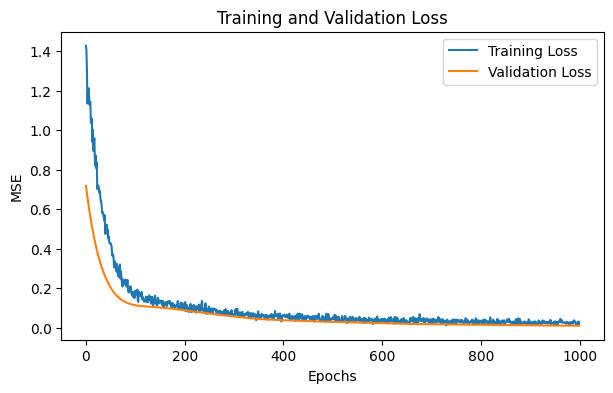

In [28]:
# Learning Curve
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(7, 4))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

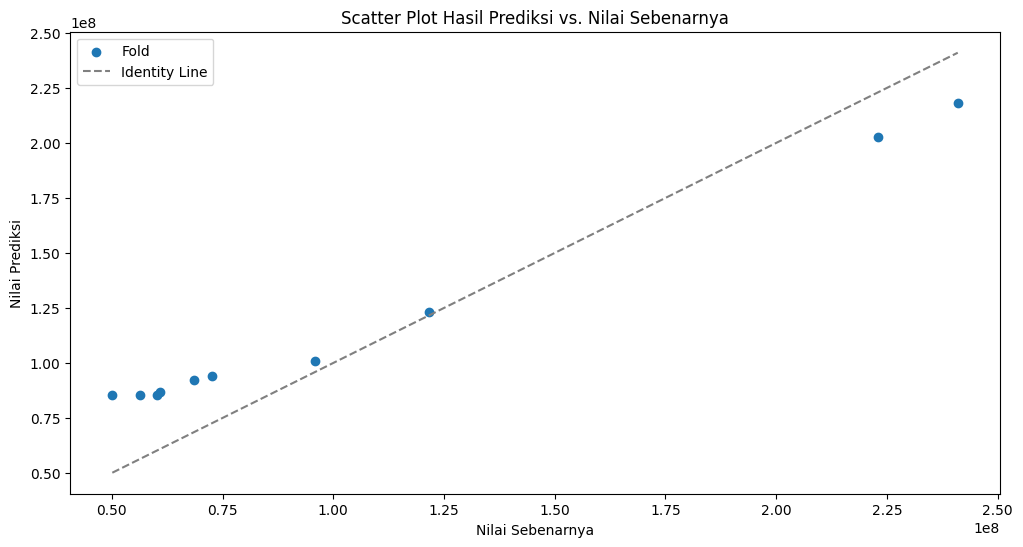

In [29]:
y_true_list = []  # List untuk menyimpan nilai sebenarnya
y_pred_list = []  # List untuk menyimpan nilai prediksi

# Simpan nilai sebenarnya dan nilai prediksi ke dalam list
y_true_list.append(scaler_y.inverse_transform(y_test))
y_pred_list.append(scaler_y.inverse_transform(y_pred))

# Scatter plot untuk setiap fold
plt.figure(figsize=(12, 6))
for fold, (y_true, y_pred) in enumerate(zip(y_true_list, y_pred_list), 1):
    plt.scatter(y_true, y_pred.flatten(), label=f'Fold')

plt.plot([min(np.concatenate(y_true_list)), max(np.concatenate(y_true_list))],
         [min(np.concatenate(y_true_list)), max(np.concatenate(y_true_list))],
         linestyle='--', color='gray', label='Identity Line')
plt.title('Scatter Plot Hasil Prediksi vs. Nilai Sebenarnya')
plt.xlabel('Nilai Sebenarnya')
plt.ylabel('Nilai Prediksi')
plt.legend()
plt.show()

In [ ]:
# Prediksi populasi untuk 5 tahun ke depan
tahun_prediksi = np.arange(2024, 2026)

# Normalisasi tahun_prediksi menggunakan scaler_X yang telah digunakan sebelumnya
tahun_prediksi_normalized = scaler_X.transform(np.array(tahun_prediksi).reshape(-1, 1))

# Prediksi dengan model
populasi_prediksi_normalized = model.predict(tahun_prediksi_normalized)

# Denormalisasi hasil prediksi
populasi_prediksi = scaler_y.inverse_transform(populasi_prediksi_normalized)

# Tampilkan hasil prediksi
for i, year in enumerate(tahun_prediksi):
    print(f'Prediksi Populasi Tahun {year}: {populasi_prediksi[i, 0]}')

1/1 [==============================] - 0s 14ms/step
Prediksi Populasi Tahun 2024: 284925728.0
Prediksi Populasi Tahun 2025: 287974016.0


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
